In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import joblib # Para carregar os scalers

import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

import time
import csv

In [2]:
# -----------------------
# Funções de pertinência
# -----------------------
def gaussmf(x, mean, sigma):
    x = np.asarray(x, dtype=np.float32)
    sigma = float(sigma) if sigma != 0 else 1e-6
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2).astype(np.float32)

def trimf(x, a, b, c):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    # rising
    idx = (x >= a) & (x <= b)
    if b != a:
        y[idx] = (x[idx] - a) / (b - a)
    # falling
    idx = (x >= b) & (x <= c)
    if c != b:
        y[idx] = (c - x[idx]) / (c - b)
    return np.clip(y, 0.0, 1.0)

def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    # rising
    idx = (x >= a) & (x <= b)
    if b != a:
        y[idx] = (x[idx] - a) / (b - a)
    # plateau
    idx = (x > b) & (x < c)
    y[idx] = 1.0
    # falling
    idx = (x >= c) & (x <= d)
    if d != c:
        y[idx] = (d - x[idx]) / (d - c)
    return np.clip(y, 0.0, 1.0)

# aproximação de pimf (pi-shaped) usando trapmf (parecido com fuzz.pimf)
def pimf(x, a, b, c, d):
    # assume a<=b<=c<=d
    return trapmf(x, a, b, c, d)

# zmf / smf (simples e eficiente)
def zmf(x, a, b):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    y[x <= a] = 1.0
    idx = (x > a) & (x < b)
    # suavização quadrática (aprox)
    denom = (b - a) if b != a else 1e-6
    y[idx] = 1.0 - ((x[idx] - a) / denom) ** 2
    return np.clip(y, 0.0, 1.0)

def smf(x, a, b):
    # mirror de zmf
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    y[x >= b] = 1.0
    idx = (x > a) & (x < b)
    denom = (b - a) if b != a else 1e-6
    y[idx] = ((x[idx] - a) / denom) ** 2
    return np.clip(y, 0.0, 1.0)

# -----------------------
# Classe do controlador rápido
# -----------------------
class FuzzyControllerFast:
    def __init__(self, parametros_vetor, n_u_vf=181, n_u_wf=181):
        """
        parametros_vetor = [z_dp, pff_dp, mp_dp, pff_m, mp_m]
        cria e precomputa MFs e regras. Reutilize esta instância para muitas chamadas.
        """
        z_dp, pff_dp, mp_dp, pff_m, mp_m = parametros_vetor
        # guardar parâmetros
        self.params = (z_dp, pff_dp, mp_dp, pff_m, mp_m)

        # universos (mesmos que seu código original)
        self.phi_univ = np.linspace(-np.pi, np.pi, 181, dtype=np.float32)
        self.l_univ   = np.linspace(0, 5, 181, dtype=np.float32)
        self.u_vf     = np.linspace(-0.15, 0.15, n_u_vf, dtype=np.float32)
        self.u_wf     = np.linspace(-0.5, 0.5, n_u_wf, dtype=np.float32)

        # construir MFs antecedentes (funções que aceitam array x and retornam pertinência)
        # NOTE: usamos closures para fixar os parâmetros
        self.antecedent_mfs = {
            'PHI': [
                ('EN', lambda x, m=-np.pi, s=z_dp: gaussmf(x, m, s)),
                ('PNR', lambda x, m=(pff_m - np.pi), s=pff_dp: gaussmf(x, m, s)),
                ('GN', lambda x, m=(mp_m - np.pi), s=mp_dp: gaussmf(x, m, s)),
                ('MN', lambda x, m=-mp_m, s=mp_dp: gaussmf(x, m, s)),
                ('PNF', lambda x, m=-pff_m, s=pff_dp: gaussmf(x, m, s)),
                ('Z', lambda x, m=0.0, s=z_dp: gaussmf(x, m, s)),
                ('PPF', lambda x, m=pff_m, s=pff_dp: gaussmf(x, m, s)),
                ('MP', lambda x, m=mp_m, s=mp_dp: gaussmf(x, m, s)),
                ('GP', lambda x, m=(np.pi - mp_m), s=mp_dp: gaussmf(x, m, s)),
                ('PPR', lambda x, m=(np.pi - pff_m), s=pff_dp: gaussmf(x, m, s)),
                ('EP', lambda x, m=np.pi, s=z_dp: gaussmf(x, m, s)),
            ],
            'L': [
                ('MP', lambda x, a=0.01, b=0.02: zmf(x, a, b)),
                ('G',  lambda x, a=0.01, b=0.02: smf(x, a, b)),
            ]
        }

        # construir MFs consequentes (pré-computados nos universos)
        # VF terms: R, MR, P, MF, F
        self.output_vf = [
            ('R',  pimf(self.u_vf, -0.151, -0.15, -0.1, -0.05)),
            ('MR', pimf(self.u_vf, -0.1, -0.05, -0.05, 0.0)),
            ('P',  pimf(self.u_vf, -0.05, 0.0, 0.0, 0.05)),
            ('MF', pimf(self.u_vf, 0.0, 0.05, 0.05, 0.1)),
            ('F',  pimf(self.u_vf, 0.05, 0.1, 0.15, 0.151)),
        ]
        # WF terms: H, N, AH
        self.output_wf = [
            ('H',  trimf(self.u_wf, -0.5, -0.5, 0.0)),
            ('N',  trimf(self.u_wf, -0.5, 0.0, 0.5)),
            ('AH', trimf(self.u_wf, 0.0, 0.5, 0.5)),
        ]

        # mapa de nomes para índices (antecedentes)
        self.phi_terms = [name for name, _ in self.antecedent_mfs['PHI']]
        self.l_terms   = [name for name, _ in self.antecedent_mfs['L']]

        # regras: cada regra tem (antecedente_indices, (vf_cons_index, wf_cons_index))
        # usamos None para variáveis não especificadas (i.e., regra só com L)
        # ordem de variáveis: [PHI, L]
        # montado diretamente a partir do seu código:
        self.rules = [
            ([None, 0], (2, 1)),   # L['MP'] -> (VF['P'], WF['N']) ; VF index 2, WF index 1
            ([0, 1],    (0, 1)),   # PHI['EN'] & L['G'] -> (VF['R'], WF['N'])
            ([1, 1],    (1, 2)),   # PNR & G -> (MR, AH)
            ([2, 1],    (2, 2)),   # GN & G -> (P, AH)
            ([3, 1],    (2, 0)),   # MN & G -> (P, H)
            ([4, 1],    (3, 0)),   # PNF & G -> (MF, H)
            ([5, 1],    (4, 1)),   # Z & G -> (F, N)
            ([6, 1],    (3, 2)),   # PPF & G -> (MF, AH)
            ([7, 1],    (2, 2)),   # MP & G -> (P, AH)
            ([8, 1],    (2, 0)),   # GP & G -> (P, H)
            ([9, 1],    (1, 0)),   # PPR & G -> (MR, H)
            ([10,1],    (0, 1)),   # EP & G -> (R, N)
        ]

    def compute(self, phi_input, l_input):
        """
        phi_input, l_input: scalars or 1D arrays (same shape). Returns array:
        - if inputs scalar -> np.array([vf, wf])
        - if vector -> array shape (N,2) with columns [vf, wf]
        """
        # normalize inputs to arrays
        phi = np.asarray(phi_input, dtype=np.float32)
        l   = np.asarray(l_input, dtype=np.float32)

        scalar_input = (phi.shape == ())  # scalar vs vector
        if scalar_input:
            phi = phi[None]
            l   = l[None]
        # shape (N,)
        N = phi.shape[0]

        # 1) calcular pertinências por termo para cada variável
        # PHI: (K_phi, N)
        K_phi = len(self.antecedent_mfs['PHI'])
        deg_phi = np.empty((K_phi, N), dtype=np.float32)
        for k, (_name, func) in enumerate(self.antecedent_mfs['PHI']):
            deg_phi[k, :] = func(phi)

        # L: (K_l, N)
        K_l = len(self.antecedent_mfs['L'])
        deg_l = np.empty((K_l, N), dtype=np.float32)
        for k, (_name, func) in enumerate(self.antecedent_mfs['L']):
            deg_l[k, :] = func(l)

        # 2) calcular ativação de cada regra (n_rules, N)
        n_rules = len(self.rules)
        rule_acts = np.empty((n_rules, N), dtype=np.float32)
        for r, (ante_idxs, _cons) in enumerate(self.rules):
            # ante_idxs: [phi_idx_or_None, l_idx_or_None]
            parts = []
            # PHI
            if ante_idxs[0] is None:
                parts.append(np.ones(N, dtype=np.float32))
            else:
                parts.append(deg_phi[ante_idxs[0], :])
            # L
            if ante_idxs[1] is None:
                parts.append(np.ones(N, dtype=np.float32))
            else:
                parts.append(deg_l[ante_idxs[1], :])
            # AND = min
            rule_acts[r, :] = np.minimum.reduce(parts)

        # 3) agregação por termo de cada saída (VF e WF)
        n_vf_terms = len(self.output_vf)
        n_wf_terms = len(self.output_wf)
        cons_vf = np.zeros((n_vf_terms, N), dtype=np.float32)
        cons_wf = np.zeros((n_wf_terms, N), dtype=np.float32)

        for r, (_ante, (vf_idx, wf_idx)) in enumerate(self.rules):
            # máximo entre regras que apontam pro mesmo termo
            cons_vf[vf_idx, :] = np.maximum(cons_vf[vf_idx, :], rule_acts[r, :])
            cons_wf[wf_idx, :] = np.maximum(cons_wf[wf_idx, :], rule_acts[r, :])

        # 4) agregação final e defuzzificação por centróide (vetorizado)
        # Montar aggregated surfaces (N x M_vf) e (N x M_wf)
        M_vf = self.u_vf.size
        M_wf = self.u_wf.size

        aggregated_vf = np.zeros((N, M_vf), dtype=np.float32)
        for j, (_name, mf_on_u) in enumerate(self.output_vf):
            # cons_vf[j,:] (N,) * mf_on_u (M_vf,)
            aggregated_vf = np.maximum(aggregated_vf, cons_vf[j, :][:, None] * mf_on_u[None, :])

        aggregated_wf = np.zeros((N, M_wf), dtype=np.float32)
        for j, (_name, mf_on_u) in enumerate(self.output_wf):
            aggregated_wf = np.maximum(aggregated_wf, cons_wf[j, :][:, None] * mf_on_u[None, :])

        # centróide
        numer_vf = np.sum(aggregated_vf * self.u_vf[None, :], axis=1)
        denom_vf = np.sum(aggregated_vf, axis=1)
        vf_out = np.where(denom_vf > 1e-12, numer_vf / denom_vf, 0.0).astype(np.float32)

        numer_wf = np.sum(aggregated_wf * self.u_wf[None, :], axis=1)
        denom_wf = np.sum(aggregated_wf, axis=1)
        wf_out = np.where(denom_wf > 1e-12, numer_wf / denom_wf, 0.0).astype(np.float32)

        # montar retorno
        if scalar_input:
            return np.array([float(vf_out[0]), float(wf_out[0])], dtype=np.float32)
        else:
            return np.column_stack([vf_out, wf_out])  # shape (N,2)

In [3]:
def simular_malha_fechada_fast(
    ctrl_fast,                # instância de FuzzyControllerFast pré-criada
    modelo_rnn,
    angulos_ideais,
    x_scaler_rnn,
    y_scaler_rnn,
    timesteps,
    L_input_constante=1.0,
    dt_coeff=0.07
):
    """
    Versão otimizada da simulação em malha fechada.
    - ctrl_fast: FuzzyControllerFast já criado (evita recriar MFs/regras cada passo)
    - modelo_rnn: modelo Keras pronto para inferência
    - angulos_ideais: vetor dos ângulos de referência
    - x_scaler_rnn, y_scaler_rnn: scalers do sklearn (ou equivalentes)
    - timesteps: tamanho da janela de entrada da RNN
    - L_input_constante: valor de L passado ao controlador
    - dt_coeff: ganho aplicado ao delta_angulo (0.07 no seu código)
    Retorna: (angulos_preditos, historico_wd, historico_we)
    """
    # constantes físicas
    R_CONST = np.float32(0.034)
    L_CONST = np.float32(0.123 / 2.0)

    # garantir tipos float32 e vetor numpy
    angulos_ideais = np.asarray(angulos_ideais, dtype=np.float32)
    N_total = angulos_ideais.size

    # inicializa saída
    angulo_atual = np.float32(angulos_ideais[0])
    angulos_preditos = np.empty_like(angulos_ideais, dtype=np.float32)
    angulos_preditos[0] = angulo_atual

    # históricos (pré-alocados) - comprimentos = N_total
    historico_wd = np.empty(N_total, dtype=np.float32)
    historico_we = np.empty(N_total, dtype=np.float32)
    historico_wd[0] = np.float32(0.0)
    historico_we[0] = np.float32(0.0)

    # usar buffer numpy circular para entradas da RNN (timesteps x 2)
    seq_buffer = np.zeros((timesteps, 2), dtype=np.float32)
    # inicializa com zeros (igual ao seu deque inicial)
    # head aponta para a posição onde inserir o próximo (simula append com deslocamento)
    head = 0

    # preparação para evitar overhead em inverse_transform:
    use_manual_y_inverse = False
    if hasattr(y_scaler_rnn, 'scale_') and hasattr(y_scaler_rnn, 'mean_'):
        # scaler padrão do sklearn: y = (X - mean)/scale  -> inverse: X = y*scale + mean
        y_scale = y_scaler_rnn.scale_.astype(np.float32)
        y_mean  = y_scaler_rnn.mean_.astype(np.float32)
        use_manual_y_inverse = True
    else:
        # fallback para usar inverse_transform
        use_manual_y_inverse = False

    # garantir que o modelo produza float32 - convertendo tensores na inferência se necessário
    # Loop causal (não dá pra evitar o loop por depender do estado atual)
    for i in range(1, N_total):
        # 1) erro phi
        erro_phi = np.float32(angulos_ideais[i-1] - angulo_atual)

        # 2) obter ação fuzzy (usa ctrl_fast.compute, vetorizado, mas com 1 amostra aqui)
        # ret = np.array([vf, wf]) ou shape (N,2) se vetor
        vf_wf = ctrl_fast.compute(np.float32(erro_phi), np.float32(L_input_constante))
        vf = np.float32(vf_wf[0])
        wf = np.float32(vf_wf[1])

        # 3) transformar em Wd, We
        W_d = (vf + (L_CONST * wf)) / R_CONST
        W_e = (vf - (L_CONST * wf)) / R_CONST

        historico_wd[i] = W_d
        historico_we[i] = W_e

        # 4) atualizar buffer circular (append)
        seq_buffer[head, 0] = W_d
        seq_buffer[head, 1] = W_e
        head = (head + 1) % timesteps

        # 5) construir janela na ordem correta para a RNN: a RNN geralmente espera [t-timesteps+1 ... t]
        # montamos de forma que a ordem temporal fique correta: pegar a porção circular
        if head == 0:
            # buffer já "complete" em ordem natural
            sequencia_entrada = seq_buffer.copy()
        else:
            # concatenar slice tail + head
            sequencia_entrada = np.vstack((seq_buffer[head:, :], seq_buffer[:head, :]))

        # 6) normalizar (x_scaler_rnn.transform aceita 2D arrays)
        # transformar toda janela de uma vez: shape (timesteps, 2)
        sequencia_norm = x_scaler_rnn.transform(sequencia_entrada.astype(np.float32))
        # reshape para (1, timesteps, 2)
        sequencia_norm_reshaped = sequencia_norm.reshape(1, timesteps, 2).astype(np.float32)

        # 7) inferência da RNN - usar chamada direta ao modelo (menos overhead que predict)
        # resultado tensor ou np.array shape (1, out_dim)
        delta_angulo_norm = modelo_rnn(sequencia_norm_reshaped, training=False)
        # garantir numpy
        if hasattr(delta_angulo_norm, 'numpy'):
            delta_angulo_norm = delta_angulo_norm.numpy()
        delta_angulo_norm = delta_angulo_norm.astype(np.float32)

        # 8) denormaliza - manual se possível
        if use_manual_y_inverse:
            # suporta saída multivariada; assumimos primeiro elemento é o delta desejado
            delta_angulo = delta_angulo_norm * y_scale + y_mean
        else:
            delta_angulo = y_scaler_rnn.inverse_transform(delta_angulo_norm)

        # 9) atualiza estado angular
        # delta_angulo pode ter shape (1,1) ou (1,)
        # extrair escalar
        da = float(np.asarray(delta_angulo).reshape(-1)[0])
        angulo_atual = np.float32(angulo_atual + da * dt_coeff)
        angulos_preditos[i] = angulo_atual

    # retornar trajetoria e históricos
    return angulos_preditos, historico_wd, historico_we

In [4]:
def funcao_custo(params):
    modelo_rnn = keras.models.load_model('../best_theta_model.keras')
    x_scaler_rnn = joblib.load('../x_scaler.gz')
    y_scaler_rnn = joblib.load('../y_scaler.gz')
    dados_ideais_df = pd.read_csv('../theta_teste.csv')
    angulos_ideais = dados_ideais_df['posicao_angular_ideal'].to_numpy()
    timesteps = 3
    ctrl_fast = FuzzyControllerFast(params) 
    angulos_preditos, hist_wd, hist_we = simular_malha_fechada_fast(
        ctrl_fast=ctrl_fast,
        modelo_rnn=modelo_rnn,
        angulos_ideais=angulos_ideais,
        x_scaler_rnn=x_scaler_rnn,
        y_scaler_rnn=y_scaler_rnn,
        timesteps=timesteps,
        L_input_constante=1.0,
        dt_coeff=0.07)
    mse = np.mean((angulos_ideais - angulos_preditos)**2)
    
    # É bom imprimir o resultado de cada tentativa para acompanhar
    print(f"Testando parâmetros... MSE Resultante: {mse:.6f}")
    
    return mse

In [5]:
def plot_graficos(angulos_preditos, angulos_ideais, hist_wd, hist_we):
    plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura
    plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)
    plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)
    plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
    plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
    plt.ylabel('Posição Angular (radianos)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    mse = np.mean((angulos_ideais - angulos_preditos)**2)
    plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
    plt.show()
    fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)
    axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
    axs[0].set_title('Sinal de Controle Wd')
    axs[0].set_ylabel('Velocidade (unidade)')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
    axs[1].set_title('Sinal de Controle We')
    axs[1].set_ylabel('Velocidade (unidade)')
    axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
    plt.show()

In [6]:
def de(costf, limites, x0, NP, itMax, tempoMax, info = True, Fp = 0.5, Cr = 0.9):
    """
    costf: função custo que recebe 1D array x (dim D) e retorna escalar
    limites: array shape (2, D) -> [xMax; xMin] (mesma ordem do Matlab)
    x0: array com soluções iniciais (pode ser None ou array k x D)
    NP: tamanho da população (int)
    itMax: iterações máximas
    tempoMax: tempo máximo em segundos
    info: bool (se True imprime e grava info)
    Fs: escalar ou array (Fp no código original)
    Cr: escalar ou array (cr no código original)
    """
    tempo_inicial = time.time()

    limites = np.asarray(limites, dtype=np.float64)
    xMax = limites[0, :].astype(np.float64)
    xMin = limites[1, :].astype(np.float64)
    D = xMax.size

    x = inicializa_populacao(xMin, xMax, x0, NP, D)

    F = np.empty(NP, dtype=np.float64)
    for n in range(NP):
        F[n] = float(costf(x[n, :]))

    # preparar Fs e Cr (broadcast se necessário)
    if np.isscalar(Fp):
        Fp = float(Fp) * np.ones(NP, dtype=np.float64)
    else:
        Fp = np.asarray(Fp, dtype=np.float64).reshape(-1)
        if Fp.size != NP:
            raise ValueError("Fs deve ser escalar ou vetor de comprimento NP")

    if np.isscalar(Cr):
        cr = float(Cr) * np.ones(NP, dtype=np.float64)
    else:
        cr = np.asarray(Cr, dtype=np.float64).reshape(-1)
        if cr.size != NP:
            raise ValueError("Cr deve ser escalar ou vetor de comprimento NP")

    it = 1
    tempo_it = 0.0

    while True:
        I = np.argmin(F)
        Fbest = float(F[I])
        gbest = x[I, :].copy()

        if (it >= itMax) or ((time.time() - tempo_inicial) + tempo_it > tempoMax):
            _info_otm(it, Fbest, gbest)
            print("\t Tempo %9.4g" % (time.time() - tempo_inicial))
            break

        if info:
            _info_otm(it, Fbest, gbest)

        v = mutacao_rand1(x, NP, Fp)

        # limitar às fronteiras
        v = np.maximum(xMin, np.minimum(xMax, v))

        u = cruzamento(x, v, NP, D, cr)

        x, F = selecao(x, F, u, costf, NP)

        it += 1

    return Fbest, gbest, it, x


def _info_otm(it, Fbest, gbest):
    print("\n\n" + "="*110)
    print(f"iter {it:3d}; \t fbest  {Fbest:9.5g}; \t gbest ", end="")
    print(",   ".join([f"{gi:9.5g}" for gi in np.atleast_1d(gbest)]))
    # gravar em CSV (append)
    row = [int(it), float(Fbest)] + [float(gi) for gi in np.atleast_1d(gbest)]
    with open("savede.csv", mode="a", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row)


def inicializa_populacao(xMin, xMax, x0, NP, D):
    x = np.empty((NP, D), dtype=np.float64)
    for d in range(D):
        x[:, d] = xMin[d] + np.random.rand(NP) * (xMax[d] - xMin[d])
    if x0 is not None and len(x0) > 0:
        x0_arr = np.asarray(x0, dtype=np.float64)
        k = min(x0_arr.shape[0], NP)
        # aplica limites
        x[:k, :] = np.maximum(np.minimum(x0_arr[:k, :], xMax), xMin)
    return x


def mutacao_rand1(x, NP, Fp):
    # Implementa: v = x(randperm(NP),:) + Fp.*(x(randperm(NP),:) - x(randperm(NP),:) );
    idx_a = np.random.permutation(NP)
    idx_b = np.random.permutation(NP)
    idx_c = np.random.permutation(NP)
    xa = x[idx_a, :]
    xb = x[idx_b, :]
    xc = x[idx_c, :]
    # Fp pode ser vetor (NP,), precisamos broadcast para (NP,1)
    Fp_col = Fp.reshape(NP, 1)
    v = xa + Fp_col * (xb - xc)
    return v


def cruzamento(x, v, NP, D, cr):
    # i = rand(NP,D) <= cr;
    # se cr é vetor, broadcast por linha
    rand_mat = np.random.rand(NP, D)
    if np.isscalar(cr) or (np.asarray(cr).ndim == 0):
        mask = rand_mat <= float(cr)
    else:
        cr_arr = np.asarray(cr).reshape(NP, 1)
        mask = rand_mat <= cr_arr
    u = x.copy()
    u[mask] = v[mask]
    return u


def selecao(x, F, u, costf, NP):
    Fu = np.empty(NP, dtype=np.float64)
    for n in range(NP):
        Fu[n] = float(costf(u[n, :]))
    for n in range(NP):
        if Fu[n] < F[n]:
            x[n, :] = u[n, :].copy()
            F[n] = Fu[n]
    return x, F

In [7]:
parametros_iniciais = [np.pi/11, np.pi/11, np.pi/11, np.pi/11, 2*np.pi/11]


limites = np.array([
    [0.3*np.pi, 0.3*np.pi, 0.3*np.pi, 0.5*np.pi, 0.5*np.pi],   # xMax (linha 1)
    [0.0,        0.0,        0.0,        0.0,        0.0     ]    # xMin (linha 2)
], dtype=float)

x0 = np.array([parametros_iniciais], dtype=float)  # shape (1, 5)

# Exemplo de chamada (comtempoMax infinito)
Fbest, gbest, it, x = de(
    costf=funcao_custo,
    limites=limites,
    x0=x0,
    NP=50,
    itMax=20,
    tempoMax=float('inf'),
    info=True,
    Fp=0.5,
    Cr=0.9
)


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Testando parâmetros... MSE Resultante: 0.005316


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Testando parâmetros... MSE Resultante: 0.013359


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


...

Testando parâmetros... MSE Resultante: 0.002458


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Testando parâmetros... MSE Resultante: 0.005335


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Testando parâmetros... MSE Resultante: 0.002062


iter  20; 	 fbest  0.00062619; 	 gbest  0.051623,    0.066302,     0.28798,     0.07302,     0.80318
	 Tempo 5.587e+04


[0.05162257 0.06630234 0.28798117 0.0730195  0.80318168]


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


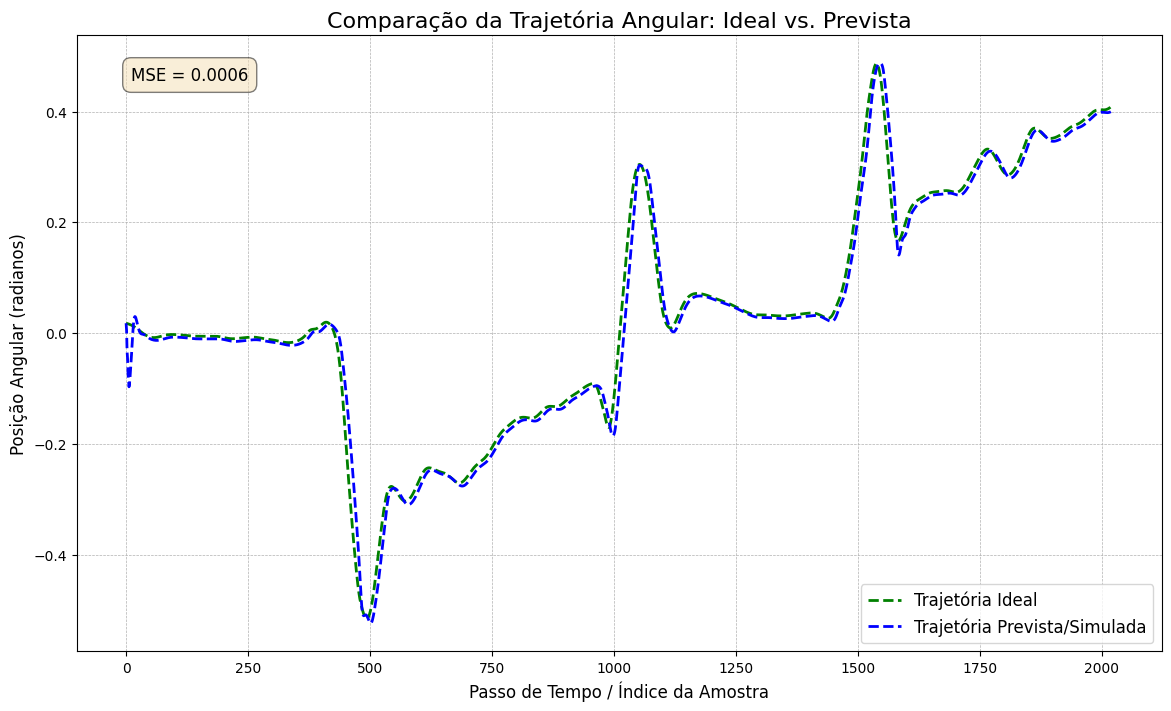

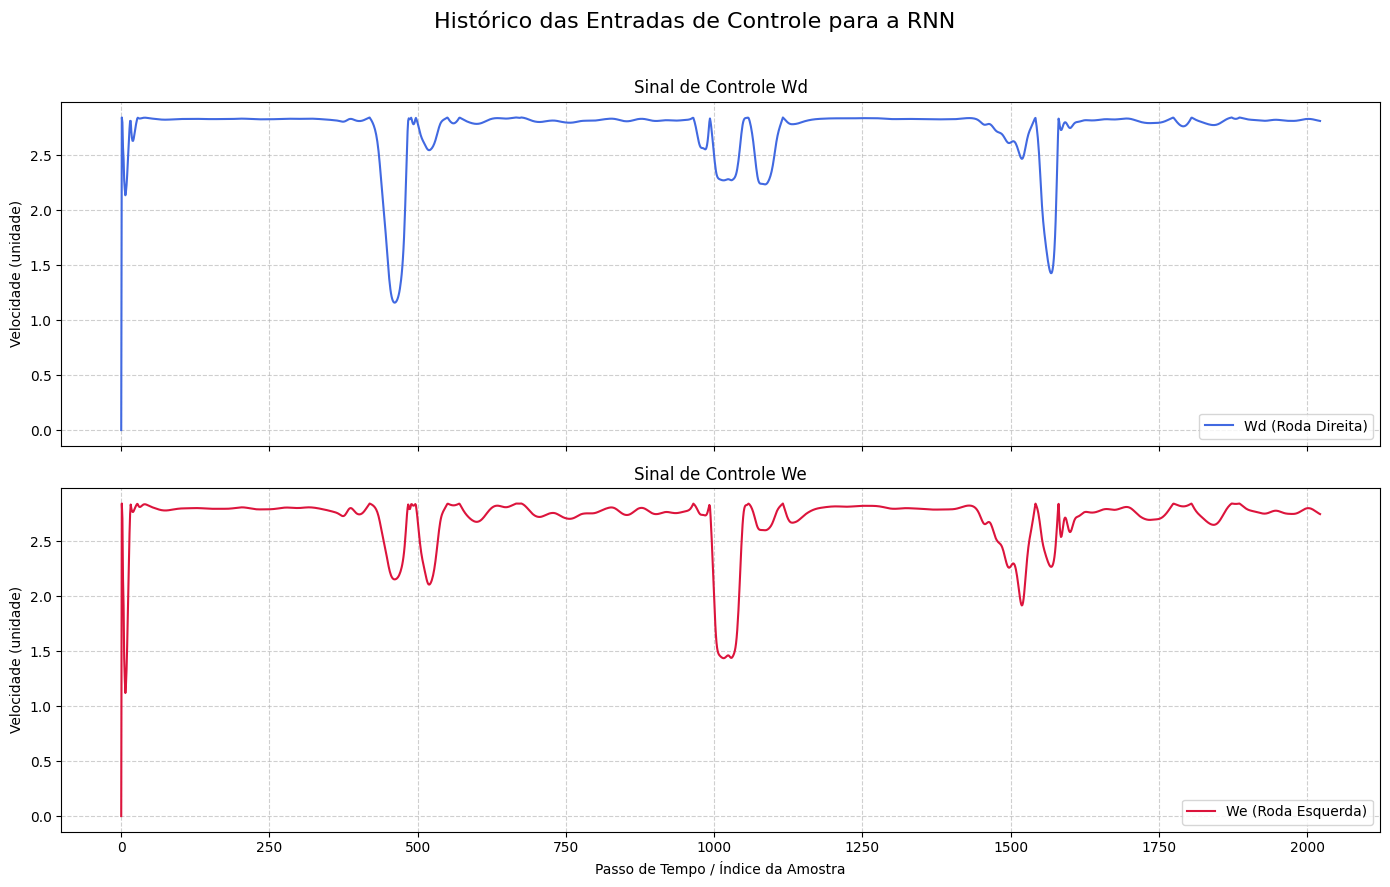

In [8]:
print(gbest)
modelo_rnn = keras.models.load_model('../best_theta_model.keras')
x_scaler_rnn = joblib.load('../x_scaler.gz')
y_scaler_rnn = joblib.load('../y_scaler.gz')
dados_ideais_df = pd.read_csv('../theta_teste.csv')
angulos_ideais = dados_ideais_df['posicao_angular_ideal'].to_numpy()
timesteps = 3
ctrl_fast = FuzzyControllerFast(gbest) 
angulos_preditos, hist_wd, hist_we = simular_malha_fechada_fast(
    ctrl_fast=ctrl_fast,
    modelo_rnn=modelo_rnn,
    angulos_ideais=angulos_ideais,
    x_scaler_rnn=x_scaler_rnn,
    y_scaler_rnn=y_scaler_rnn,
    timesteps=timesteps,
    L_input_constante=1.0,
    dt_coeff=0.07)

plot_graficos(angulos_preditos, angulos_ideais, hist_wd, hist_we)